In [1]:
import numpy, pandas, sklearn, sys
print("Python:", sys.version)
print("NumPy:", numpy.__version__, "| pandas:", pandas.__version__, "| scikit-learn:", sklearn.__version__)


Python: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
NumPy: 2.0.2 | pandas: 2.2.2 | scikit-learn: 1.6.1


In [2]:
%pip install -q snownlp==0.12.3 jieba==0.42.1 gensim==4.3.2 tqdm openpyxl


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 54.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 63.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
# @title Config: paths, columns, thresholds, outdir
from pathlib import Path
import re

# --- Input files (replace with your actual paths) ---
DATA1_PATH = "/content/1911-1937_merged_sorted.xlsx"
DATA2_PATH = "/content/1938-1949_merged_sorted.xlsx"

# --- Columns ---
TITLE_COL = "Title"
TIME_COL  = "Time"   # parseable datetime string

# --- Regex for '她'
TA_REGEX = re.compile(r"她")

# --- Year bounds for sanity check
MIN_YEAR, MAX_YEAR = 1850, 2000

# --- Dynamic thresholds (tri-label)
POS_TH = 0.60     # >= 0.60 => positive
NEG_TH = 0.40     # <= 0.40 => negative
SHORT_TITLE_LEN = 6
SHORT_POS_TH    = 0.65
SHORT_NEG_TH    = 0.35

#--- Use word-level tokenization
USE_JIEBA = True          # ← turn on jieba word mode
MIN_TOKEN_FREQ = 3        # keep words with freq >= 3 in vocab tables
MIN_WORD_LEN = 2          # drop 1-char words (often function words/punct)


# --- SentProp params
EMB_DIM   = 100
WINDOW    = 5
MIN_COUNT = 3         # embedding's minimum token count (<= MIN_TOKEN_FREQ)
K_NEIGH   = 20        # k-NN graph
BETA      = 0.85      # random walk restart: p = beta*T*p + (1-beta)*seed
N_ITERS   = 50
BOOT_B    = 100       # bootstrap rounds
BOOT_KEEP = 0.8       # keep ratio of seeds per bootstrap

# --- Output directory
OUTDIR = "/content/outputs_nlp"
Path(OUTDIR).mkdir(parents=True, exist_ok=True)


In [4]:
# @title (Optional) Mount Google Drive or upload files
# from google.colab import drive
# drive.mount('/content/drive')

# Or manual upload:
# from google.colab import files
# uploaded = files.upload()


In [5]:
# @title Load datasets, normalize dates, add '她' flag
import pandas as pd
import numpy as np
from IPython.display import display

def load_any(path: str) -> pd.DataFrame:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"File not found: {p}")
    if p.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(p)
    elif p.suffix.lower() in [".csv", ".txt"]:
        return pd.read_csv(p)
    else:
        raise ValueError(f"Unsupported file type: {p.suffix}")

def normalize_to_year(df: pd.DataFrame, time_col: str) -> pd.DataFrame:
    out = df.copy()
    out["_time_raw"] = out[time_col]
    out[time_col] = pd.to_datetime(out[time_col], errors="coerce")
    out["year"] = out[time_col].dt.year
    out.loc[~out["year"].between(MIN_YEAR, MAX_YEAR, inclusive="both"), "year"] = np.nan
    return out

def add_ta_flag(df: pd.DataFrame, title_col: str) -> pd.DataFrame:
    out = df.copy()
    out["title_has_ta"] = out[title_col].astype(str).apply(lambda x: 1 if TA_REGEX.search(x) else 0)
    return out

df1 = load_any(DATA1_PATH); df2 = load_any(DATA2_PATH)
for df in (df1, df2):
    assert TITLE_COL in df.columns and TIME_COL in df.columns, "Missing title/time columns."

df1 = df1.rename(columns={TITLE_COL:"_title", TIME_COL:"_time"}); df1["_group"]="G1_pre"
df2 = df2.rename(columns={TITLE_COL:"_title", TIME_COL:"_time"}); df2["_group"]="G2_post"

df1 = add_ta_flag(normalize_to_year(df1, "_time"), "_title")
df2 = add_ta_flag(normalize_to_year(df2, "_time"), "_title")

print("Shapes:", df1.shape, df2.shape)
display(df1.head(3)); display(df2.head(3))


Shapes: (20177, 14) (69123, 14)


,_title,Author,Newspaper Title,_time,藏馆,馆藏索取号,分类号,SourceFile,FileNumber,RowInFile,_group,_time_raw,year,title_has_ta
0,野史氏辨狱丛谈,逸民,民立报,1911-01-11,NaN,NaN,NaN,Newspaper/1.txt,1,1,G1_pre,1911-01-11,1911.0,0
1,政党组织之必要,佩,绍兴公报,1911-01-17,NaN,NaN,NaN,Newspaper/1.txt,1,2,G1_pre,1911-01-17,1911.0,0
2,论大隈伯对待淸国谈之谬妄（续昨）,因,绍兴公报,1911-01-20,NaN,NaN,NaN,Newspaper/1.txt,1,3,G1_pre,1911-01-20,1911.0,0


,_title,Author,Newspaper Title,_time,藏馆,馆藏索取号,分类号,SourceFile,FileNumber,RowInFile,_group,_time_raw,year,title_has_ta
0,今午公共租界内 发生连续炸弹案,NaN,大美晚报,1938-01-01,NaN,NaN,NaN,1938-1949/1.txt,1,1,G2_post,1938-01-01,1938.0,0
1,本报今晨接到 一秘密团体函件,NaN,大美晚报,1938-01-01,NaN,NaN,NaN,1938-1949/1.txt,1,2,G2_post,1938-01-01,1938.0,0
2,济南南面有前哨战,NaN,大美晚报,1938-01-01,NaN,NaN,NaN,1938-1949/1.txt,1,3,G2_post,1938-01-01,1938.0,0


[G1_pre] total=20,177, TA share=0.92%


,count_all,count_ta,share_ta
year,,,
1928.0,665,6,0.009023
1929.0,92,5,0.054348
1930.0,683,12,0.017570
1931.0,822,11,0.013382
1932.0,369,24,0.065041
1933.0,3154,26,0.008244
1934.0,2421,13,0.005370
1935.0,2944,23,0.007812
1936.0,3103,26,0.008379


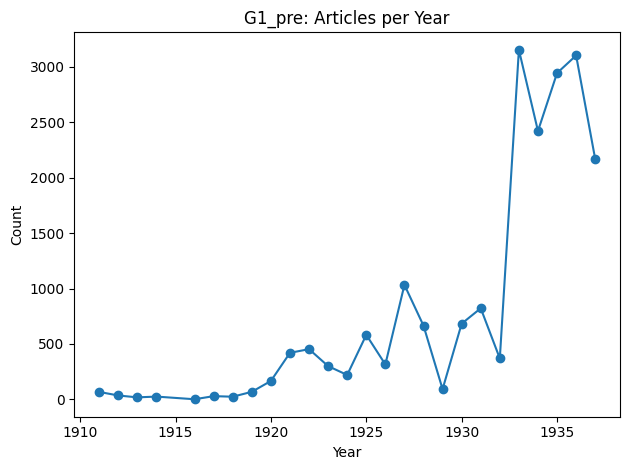

/tmp/ipython-input-1699768232.py:25: UserWarning: Glyph 22905 (\N{CJK UNIFIED IDEOGRAPH-5979}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22905 (\N{CJK UNIFIED IDEOGRAPH-5979}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


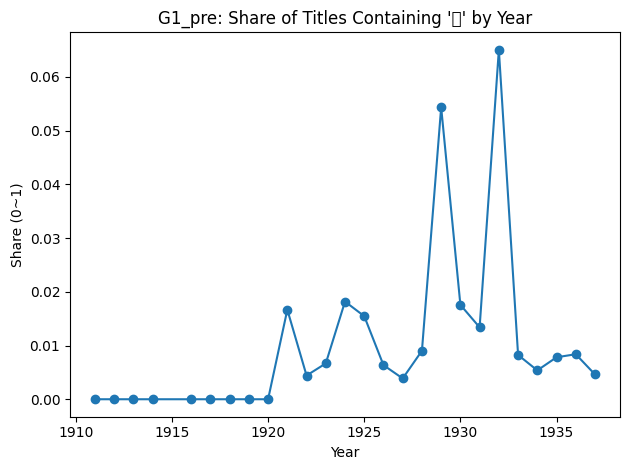

/tmp/ipython-input-1699768232.py:32: UserWarning: Glyph 22905 (\N{CJK UNIFIED IDEOGRAPH-5979}) missing from font(s) DejaVu Sans.
  plt.axis("equal"); plt.tight_layout(); plt.show()
/tmp/ipython-input-1699768232.py:32: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  plt.axis("equal"); plt.tight_layout(); plt.show()
/tmp/ipython-input-1699768232.py:32: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.axis("equal"); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


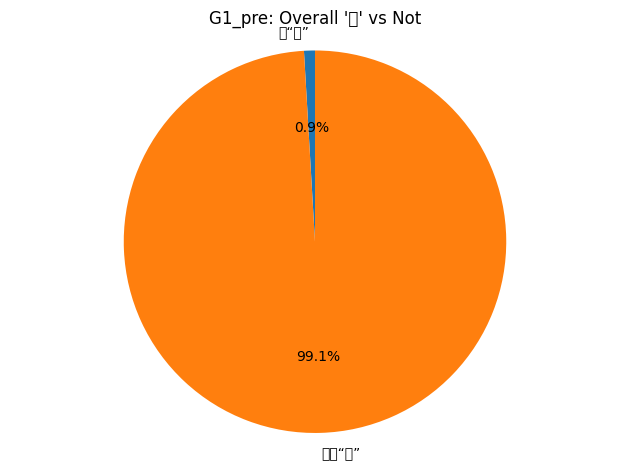

[G2_post] total=69,123, TA share=0.43%


,count_all,count_ta,share_ta
year,,,
1940.0,3872,23,0.005940
1941.0,3594,31,0.008625
1942.0,3923,7,0.001784
1943.0,4591,22,0.004792
1944.0,5240,22,0.004198
1945.0,4636,21,0.004530
1946.0,8102,36,0.004443
1947.0,8361,49,0.005861
1948.0,8642,32,0.003703


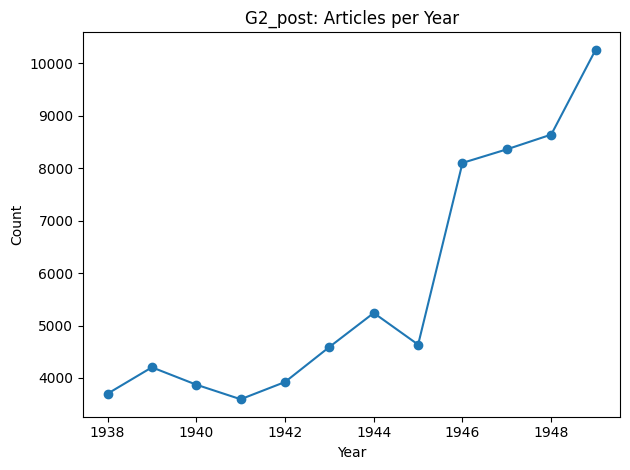

/tmp/ipython-input-1699768232.py:25: UserWarning: Glyph 22905 (\N{CJK UNIFIED IDEOGRAPH-5979}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22905 (\N{CJK UNIFIED IDEOGRAPH-5979}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


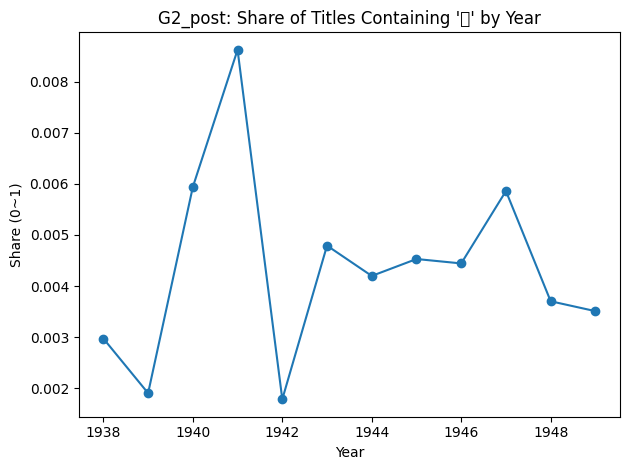

/tmp/ipython-input-1699768232.py:32: UserWarning: Glyph 22905 (\N{CJK UNIFIED IDEOGRAPH-5979}) missing from font(s) DejaVu Sans.
  plt.axis("equal"); plt.tight_layout(); plt.show()
/tmp/ipython-input-1699768232.py:32: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  plt.axis("equal"); plt.tight_layout(); plt.show()
/tmp/ipython-input-1699768232.py:32: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.axis("equal"); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


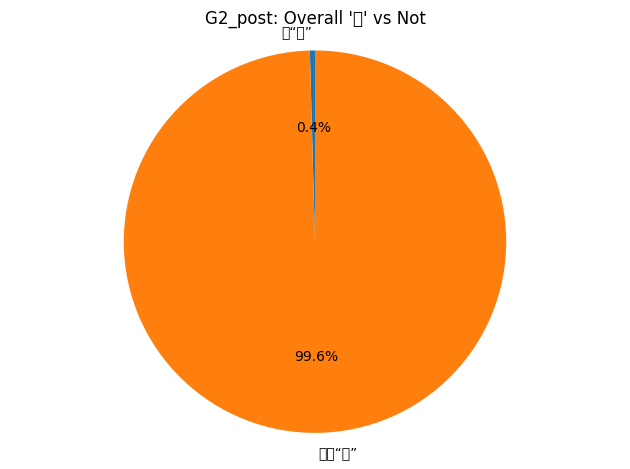

In [6]:
# @title Basic profiling: yearly counts, yearly '她' share, overall pie
import matplotlib.pyplot as plt

def basic_profile(df: pd.DataFrame, name: str):
    total = len(df)
    ta_share = df["title_has_ta"].mean() if total else 0.0
    year_tab = df.pivot_table(index="year", values="title_has_ta", aggfunc=["count","sum"])
    year_tab.columns = ["count_all","count_ta"]
    year_tab["share_ta"] = year_tab["count_ta"] / year_tab["count_all"]
    print(f"[{name}] total={total:,}, TA share={ta_share:.2%}")
    display(year_tab.tail(10))

    # Yearly counts
    plt.figure()
    plt.plot(year_tab.index, year_tab["count_all"], marker="o")
    plt.title(f"{name}: Articles per Year")
    plt.xlabel("Year"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

    # Yearly share of '她'
    plt.figure()
    plt.plot(year_tab.index, year_tab["share_ta"], marker="o")
    plt.title(f"{name}: Share of Titles Containing '她' by Year")
    plt.xlabel("Year"); plt.ylabel("Share (0~1)")
    plt.tight_layout(); plt.show()

    # Overall pie
    ta_count = int(df["title_has_ta"].sum()); not_count = int(total - ta_count)
    plt.figure()
    plt.pie([ta_count, not_count], labels=["含“她”","不含“她”"], autopct="%1.1f%%", startangle=90)
    plt.title(f"{name}: Overall '她' vs Not")
    plt.axis("equal"); plt.tight_layout(); plt.show()

    year_tab.to_csv(f"{OUTDIR}/{name}_year_profile.csv", encoding="utf-8-sig")
    return year_tab

prof1 = basic_profile(df1, "G1_pre")
prof2 = basic_profile(df2, "G2_post")


In [7]:
# @title Combine two datasets
common_cols = list(set(df1.columns) & set(df2.columns))
combined = pd.concat([df1[common_cols], df2[common_cols]], ignore_index=True)
combined["_dataset"] = np.where(combined["_group"]=="G1_pre", "1911-1937", "1938-1949")
print("Combined shape:", combined.shape)
combined.head(3)


Combined shape: (89300, 15)


,_group,FileNumber,藏馆,year,RowInFile,_time_raw,Author,馆藏索取号,_title,SourceFile,Newspaper Title,_time,分类号,title_has_ta,_dataset
0,G1_pre,1,NaN,1911.0,1,1911-01-11,逸民,NaN,野史氏辨狱丛谈,Newspaper/1.txt,民立报,1911-01-11,NaN,0,1911-1937
1,G1_pre,1,NaN,1911.0,2,1911-01-17,佩,NaN,政党组织之必要,Newspaper/1.txt,绍兴公报,1911-01-17,NaN,0,1911-1937
2,G1_pre,1,NaN,1911.0,3,1911-01-20,因,NaN,论大隈伯对待淸国谈之谬妄（续昨）,Newspaper/1.txt,绍兴公报,1911-01-20,NaN,0,1911-1937


In [8]:
# Word-level tokenization with jieba; light normalization and stopwords
import re, jieba
import pandas as pd
from collections import Counter

# Minimal stopwords & punct (可按需要扩充)
STOPWORDS = set(list("的了之其与及并而在对以于等是有无者人我们你他们她它本各诸何其若"))
PUNCT = set(list("，。、“”‘’：；！？—（）()【】[]《》<>—-·．… ,.:;!?\"'"))

def normalize_zh(text: str) -> str:
    s = str(text)
    # 全角→半角
    res = []
    for ch in s:
        code = ord(ch)
        if code == 0x3000:
            ch = ' '
        elif 0xFF01 <= code <= 0xFF5E:
            ch = chr(code - 0xFEE0)
        res.append(ch)
    s = "".join(res)
    # 去掉明显的噪声空白
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenize_word(text: str):
    s = normalize_zh(text)
    toks = []
    for w in jieba.lcut(s):
        w = w.strip()
        if (not w) or (w in STOPWORDS) or (w in PUNCT):
            continue
        if len(w) < MIN_WORD_LEN:
            continue
        if w.isdigit():
            continue
        toks.append(w)
    return toks

# Re-tokenize to WORDS
combined["tokens"] = combined["_title"].astype(str).apply(tokenize_word)

# Word frequency
from collections import Counter
all_tokens = [t for toks in combined["tokens"] for t in toks]
cnt = Counter(all_tokens)
freq_df = (pd.DataFrame(cnt.items(), columns=["token","freq"])
           .query("freq >= @MIN_TOKEN_FREQ")
           .sort_values("freq", ascending=False)
           .reset_index(drop=True))
freq_df.to_csv(f"{OUTDIR}/token_freq_words.csv", index=False, encoding="utf-8-sig")
print("Saved word frequencies ->", f"{OUTDIR}/token_freq_words.csv")
freq_df.head(30)


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 1.336 seconds.
DEBUG:jieba:Loading model cost 1.336 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


Saved word frequencies -> /content/outputs_nlp/token_freq_words.csv


,token,freq
0,妇女,1822
1,问题,1149
2,中国,1106
3,苏联,983
4,一个,881
5,美国,866
6,女士,811
7,生活,771
8,人民,769
9,日本,706


In [9]:
# @title Use fixed seeds (your lists) and export seed_final.csv
# Paste-and-run to override any previous seed-generation logic.

import pandas as pd
from pathlib import Path

# === Your seeds (as provided) ===
pos_seeds = "和平 胜利 建设 发展 自由 团结 合作 成功 努力 进步 幸福 光荣 复兴 改善 保障 慰问 贡献 正义 安定 勇敢 稳定 奖励 荣誉 繁荣 文明 赞扬 真诚 嘉奖 先进 信义 安宁 善良".split()
neg_seeds = "危机 暴行 失败 轰炸 纠纷 破坏 压迫 撤退 恐怖 沦陷 堕落 谣言 残酷 剥削 灾难 屠杀 混乱 悲惨 耻辱 动乱 贫困 丑恶 恐慌 压榨 残暴 伤亡 骚乱 围困 饥荒 惨重 卑鄙".split()

# === Optional: keep only tokens that actually exist in your vocab (from freq_df) ===
ENFORCE_IN_VOCAB = True

if ENFORCE_IN_VOCAB and "freq_df" in globals():
    vocab = set(freq_df["token"].astype(str))
    pos_in = [w for w in pos_seeds if w in vocab]
    neg_in = [w for w in neg_seeds if w in vocab]
    missing_pos = [w for w in pos_seeds if w not in vocab]
    missing_neg = [w for w in neg_seeds if w not in vocab]
else:
    pos_in, neg_in = pos_seeds, neg_seeds
    missing_pos, missing_neg = [], []

# === Export to seed_final.csv (two columns: token,label) ===
seed_final = pd.concat([
    pd.DataFrame({"token": pos_in, "label": "positive"}),
    pd.DataFrame({"token": neg_in, "label": "negative"})
], ignore_index=True)

Path(OUTDIR).mkdir(parents=True, exist_ok=True)
out_path = f"{OUTDIR}/seed_final.csv"
seed_final.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"Saved final seeds -> {out_path}")
print(f"Positive: {len(pos_in)}  |  Negative: {len(neg_in)}")
if missing_pos or missing_neg:
    print("\n[Note] These seeds were not found in your vocab (freq_df) and were skipped:")
    if missing_pos: print("  Missing POS:", "、".join(missing_pos))
    if missing_neg: print("  Missing NEG:", "、".join(missing_neg))

display(seed_final.head(20))


Saved final seeds -> /content/outputs_nlp/seed_final.csv
Positive: 32  |  Negative: 31


,token,label
0,和平,positive
1,胜利,positive
2,建设,positive
3,发展,positive
4,自由,positive
5,团结,positive
6,合作,positive
7,成功,positive
8,努力,positive
9,进步,positive


In [10]:
# @title Load final seeds (or fallback to defaults)
seed_final_path = Path(f"{OUTDIR}/seed_final.csv")
if seed_final_path.exists():
    seed_final = pd.read_csv(seed_final_path)
    seed_final["label"] = seed_final["label"].str.strip().str.lower()
    pos_seeds = seed_final.loc[seed_final["label"]=="positive","token"].tolist()
    neg_seeds = seed_final.loc[seed_final["label"]=="negative","token"].tolist()
    print(f"Loaded final seeds: +{len(pos_seeds)} / -{len(neg_seeds)}")
else:
    print("No seed_final.csv found. Using defaults from Step 7.")
    pos_seeds = seed_pos
    neg_seeds = seed_neg

assert len(pos_seeds)>0 and len(neg_seeds)>0, "Need at least 1 positive and 1 negative seed."


Loaded final seeds: +32 / -31


In [11]:
# @title SentProp minimal runnable (PPMI+SVD backend, no gensim)
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from tqdm.auto import tqdm
from math import log
import scipy.sparse as sp

# ---- Hyperparams ----
EMB_DIM   = 100
WINDOW    = 5
MIN_COUNT = 3
K_NEIGH   = 20
BETA      = 0.85
N_ITERS   = 50
BOOT_B    = 100
BOOT_KEEP = 0.8
MAX_VOCAB = 30000

# 1) Build vocab from tokens
corpus = combined["tokens"].tolist()
freq = defaultdict(int)
for toks in corpus:
    for t in toks:
        freq[t] += 1

vocab_sorted = sorted([t for t,c in freq.items() if c >= MIN_COUNT],
                      key=lambda x: freq[x], reverse=True)[:MAX_VOCAB]
tok2id = {t:i for i,t in enumerate(vocab_sorted)}
id2tok = vocab_sorted
V = len(id2tok)
print("Vocab size:", V)
assert V > 10, "Vocabulary too small; check tokenization or MIN_COUNT."

# 2) Windowed co-occurrence (symmetric)
pair_count = defaultdict(int)
for toks in corpus:
    ids = [tok2id[t] for t in toks if t in tok2id]
    L = len(ids)
    for i in range(L):
        wi = ids[i]
        left  = max(0, i-WINDOW)
        right = min(L, i+WINDOW+1)
        for j in range(left, right):
            if j == i: continue
            wj = ids[j]
            if wi == wj: continue
            a, b = (wi, wj) if wi < wj else (wj, wi)
            pair_count[(a,b)] += 1

rows, cols, vals = [], [], []
for (i,j), c in pair_count.items():
    rows.append(i); cols.append(j); vals.append(float(c))
A_up = sp.coo_matrix((np.array(vals), (np.array(rows), np.array(cols))), shape=(V,V))
A = (A_up + A_up.T).tocoo()

# 3) PPMI
row_sum = np.array(A.sum(axis=1)).ravel()
col_sum = np.array(A.sum(axis=0)).ravel()
N = float(row_sum.sum()) + 1e-12
pi = row_sum / N
pj = col_sum / N

data_ppmi = []
for i, j, cij in zip(A.row, A.col, A.data):
    pij = cij / N
    denom = pi[i] * pj[j] + 1e-12
    pmi = log(pij / denom, 2)
    data_ppmi.append(max(0.0, pmi))

PPMI = sp.coo_matrix((np.array(data_ppmi), (A.row, A.col)), shape=(V,V)).tocsr()

# 4) Truncated SVD -> embeddings
svd = TruncatedSVD(n_components=EMB_DIM, n_iter=10, random_state=42)
vecs = svd.fit_transform(PPMI)

# 5) kNN graph (cosine)
norms = np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12
vecs_n = vecs / norms
nn = NearestNeighbors(n_neighbors=min(K_NEIGH+1, V), metric="cosine")
nn.fit(vecs_n)
dist, idx = nn.kneighbors(vecs_n, return_distance=True)  # includes self
rows_tr = []
for i in range(V):
    neigh = idx[i][1:]
    sims = 1.0 - dist[i][1:]
    sims = np.maximum(sims, 0.0)
    s = sims.sum() + 1e-12
    rows_tr.append((neigh, sims/s))  # transition row

# 6) Random walk with restart
def rwr(seed_tokens, beta=BETA, n_iters=N_ITERS):
    s = np.zeros(V, dtype=np.float32)
    valid = [tok2id[t] for t in seed_tokens if t in tok2id]
    assert len(valid) > 0, f"No seeds found in vocab: {seed_tokens[:5]}..."
    s[valid] = 1.0 / len(valid)
    p = s.copy()
    for _ in range(n_iters):
        p_next = np.zeros_like(p)
        for i in range(V):
            neigh, weights = rows_tr[i]
            p_next[i] = beta * np.dot(weights, p[neigh]) + (1.0 - beta) * s[i]
        p = p_next
    return p

# seeds (use already-loaded; otherwise fallback)
try:
    pos_seeds, neg_seeds
except NameError:
    pos_seeds = "和平 胜利 建设 发展 自由 团结 合作 成功 努力 进步 幸福 光荣 复兴 改善 保障 慰问 贡献 正义 安定 勇敢 稳定 奖励 荣誉 繁荣 文明 赞扬 真诚 嘉奖 先进 信义 安宁 善良".split()
    neg_seeds = "危机 暴行 失败 轰炸 纠纷 破坏 压迫 撤退 恐怖 沦陷 堕落 谣言 残酷 剥削 灾难 屠杀 混乱 悲惨 耻辱 动乱 贫困 丑恶 恐慌 压榨 残暴 伤亡 骚乱 围困 饥荒 惨重 卑鄙".split()

p_pos = rwr(pos_seeds)
p_neg = rwr(neg_seeds)
eps = 1e-9
score01 = p_pos / (p_pos + p_neg + eps)
z = (score01 - score01.mean()) / (score01.std() + 1e-9)

# 7) Bootstrap CIs
def bootstrap_scores(B=BOOT_B, keep=BOOT_KEEP, seed=42):
    rng = np.random.default_rng(seed)
    zs = []
    for _ in tqdm(range(B), desc="Bootstrap"):
        kpos = max(1, int(len(pos_seeds)*keep))
        kneg = max(1, int(len(neg_seeds)*keep))
        pos_sub = rng.choice(pos_seeds, size=kpos, replace=False)
        neg_sub = rng.choice(neg_seeds, size=kneg, replace=False)
        ppos = rwr(pos_sub); pneg = rwr(neg_sub)
        sc = ppos / (ppos + pneg + eps)
        zsc = (sc - sc.mean()) / (sc.std() + 1e-9)
        zs.append(zsc)
    return np.stack(zs, axis=0)

boot = bootstrap_scores()
ci_low = np.percentile(boot, 2.5, axis=0)
ci_high= np.percentile(boot,97.5, axis=0)
std    = boot.std(axis=0)

lex = pd.DataFrame({
    "token": id2tok,
    "score01": score01,
    "zscore": z,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "std": std
}).sort_values("zscore", ascending=False).reset_index(drop=True)

lex_path = f"{OUTDIR}/sentprop_lexicon_ppmi.csv"
lex.to_csv(lex_path, index=False, encoding="utf-8-sig")
print("Saved lexicon ->", lex_path)
lex.head(10)



Vocab size: 13793


Bootstrap:   0%|          | 0/100 [00:00<?, ?it/s]

Saved lexicon -> /content/outputs_nlp/sentprop_lexicon_ppmi.csv


,token,score01,zscore,ci_low,ci_high,std
0,真诚,1.000000,1.672424,-1.799551,1.863078,1.394531
1,安宁,0.999994,1.672401,0.962598,1.803540,0.260930
2,托儿,0.999966,1.672300,1.006228,1.803447,0.247609
3,讲演会,0.999964,1.672294,1.002160,1.803441,0.250652
4,喝酒,0.999964,1.672292,0.994374,1.803439,0.250170
5,行路难,0.999964,1.672292,1.062289,1.803439,0.226297
6,天快,0.999964,1.672291,1.062646,1.803439,0.226151
7,出版界,0.999963,1.672291,0.995191,1.803438,0.252975
8,韶关,0.999963,1.672289,1.063044,1.803436,0.227952
9,金屋,0.999962,1.672287,1.041893,1.803435,0.232746


In [12]:
# @title Lexicon coverage after SentProp (counts & ratios)
import numpy as np
import pandas as pd

lex_map = set(lex["token"].astype(str))

def lex_hits(tokens):
    return sum(1 for t in tokens if t in lex_map)

_tmp = combined[["_title","_group","tokens"]].copy()
_tmp["lex_hit_cnt"] = _tmp["tokens"].apply(lex_hits)
_tmp["lex_has_any"] = _tmp["lex_hit_cnt"] > 0

N = len(_tmp)
c_any = int(_tmp["lex_has_any"].sum())
print(f"Titles with ≥1 lexicon hit: {c_any}/{N} ({c_any/N:.1%})")
print(f"Median lex hits per title: {np.median(_tmp['lex_hit_cnt']):.1f}")

if "_group" in _tmp.columns:
    g = (_tmp.assign(has_any=_tmp["lex_has_any"])
         .groupby("_group")
         .agg(total=("has_any","size"),
              any_cnt=("has_any","sum"),
              any_ratio=("has_any","mean"),
              median_hits=("lex_hit_cnt","median"))
         .reset_index())
    display(g)


Titles with ≥1 lexicon hit: 81679/89300 (91.5%)
Median lex hits per title: 2.0


,_group,total,any_cnt,any_ratio,median_hits
0,G1_pre,20177,17835,0.883927,2.0
1,G2_post,69123,63844,0.923629,2.0


In [13]:
# @title Title scoring (lexicon-only mean; no backoffs)
import numpy as np
import pandas as pd

# Build lookup: token -> score01 from the SentProp lexicon
lex_dict = dict(zip(lex["token"].astype(str), lex["score01"].astype(float)))

# Minimum number of lexicon hits required to score a title.
# With your 91% coverage, MIN_HITS=1 is fine; set to 2 if you want to be stricter.
MIN_HITS = 1

def title_score_lex_only(tokens):
    """
    Average the SentProp scores of tokens that exist in the lexicon.
    Return (score, num_hits). If hits < MIN_HITS, return (NaN, 0).
    """
    vals = [lex_dict[t] for t in tokens if t in lex_dict]
    if len(vals) >= MIN_HITS:
        return float(np.mean(vals)), len(vals)
    return np.nan, 0

scores, hits = [], []
for toks in combined["tokens"]:
    s, k = title_score_lex_only(toks)
    scores.append(s); hits.append(k)

combined["sentprop_score"] = scores      # continuous score in [0,1]
combined["lex_hits"] = hits              # how many tokens contributed

# Quick sanity check
n = len(combined)
n_scored = n - int(pd.isna(combined["sentprop_score"]).sum())
print(f"Scored titles: {n_scored}/{n} ({n_scored/n:.1%})  |  MIN_HITS = {MIN_HITS}")

# (Optional) per-group scoring coverage
if "_group" in combined.columns:
    g = (combined.assign(has_score=~pd.isna(combined["sentprop_score"]))
         .groupby("_group")["has_score"].mean().rename("scored_ratio").reset_index())
    display(g)


Scored titles: 81679/89300 (91.5%)  |  MIN_HITS = 1


,_group,scored_ratio
0,G1_pre,0.883927
1,G2_post,0.923629


In [14]:
# @title 3-way labeling with dynamic thresholds (short-title aware)
import numpy as np

# Ensure thresholds exist (if you didn't run your earlier config cell)
POS_TH = globals().get("POS_TH", 0.60)
NEG_TH = globals().get("NEG_TH", 0.40)
SHORT_TITLE_LEN = globals().get("SHORT_TITLE_LEN", 6)
SHORT_POS_TH = globals().get("SHORT_POS_TH", 0.65)
SHORT_NEG_TH = globals().get("SHORT_NEG_TH", 0.35)

# How to handle NaN scores: 'neutral' (default) or 'drop'
NA_POLICY = 'neutral'

def dynamic_trilean_label(score, title,
                          base_pos=POS_TH, base_neg=NEG_TH,
                          short_pos=SHORT_POS_TH, short_neg=SHORT_NEG_TH,
                          short_len=SHORT_TITLE_LEN):
    """
    Convert a continuous score to {positive, neutral, negative}.
    Use stricter thresholds for very short titles.
    """
    tlen = len(str(title))
    pos_th = short_pos if tlen < short_len else base_pos
    neg_th = short_neg if tlen < short_len else base_neg
    if score >= pos_th:  return "positive"
    if score <= neg_th:  return "negative"
    return "neutral"

df_use = combined.copy()
if NA_POLICY == 'drop':
    before = len(df_use)
    df_use = df_use.dropna(subset=["sentprop_score"]).reset_index(drop=True)
    print(f"Dropped {before - len(df_use)} titles with NaN scores (NA_POLICY='drop').")
else:
    # Neutral for NaN (keeps row count unchanged)
    df_use["sentprop_score"] = df_use["sentprop_score"].fillna(0.5)

# Apply 3-way and (optional) 2-way labels
df_use["sp_label_3way"] = [dynamic_trilean_label(s, t) for s, t in zip(df_use["sentprop_score"], df_use["_title"])]
df_use["sp_label_2way"] = np.where(df_use["sentprop_score"]>=0.5, "positive", "negative")

# Write back to `combined` (keeps your downstream variable consistent)
combined = df_use

# Quick distribution
dist = combined["sp_label_3way"].value_counts(normalize=True)\
       .reindex(["negative","neutral","positive"]).fillna(0)
print("3-way class distribution:")
display(dist.to_frame("ratio").T)


3-way class distribution:


sp_label_3way,negative,neutral,positive
ratio,0.204211,0.374356,0.421433


Overall 3-way ratios:


sp_label_3way,negative,neutral,positive
ratio,0.204211,0.374356,0.421433


By-group 3-way ratios:


sp_label_3way,negative,neutral,positive
_group,,,
G1_pre,0.210091,0.396987,0.392923
G2_post,0.202494,0.367750,0.429756


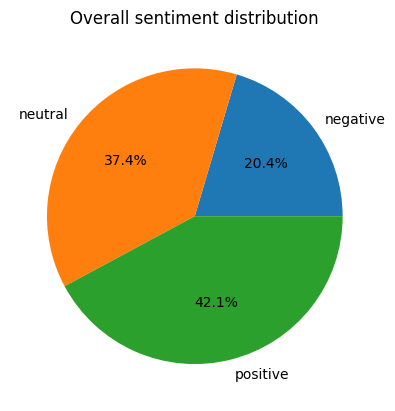

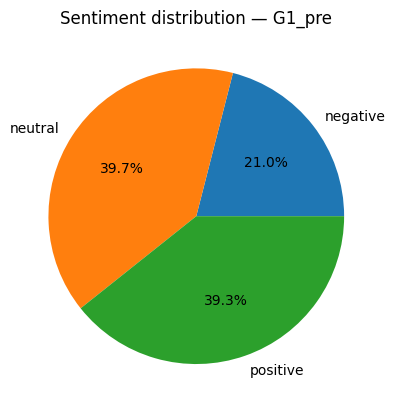

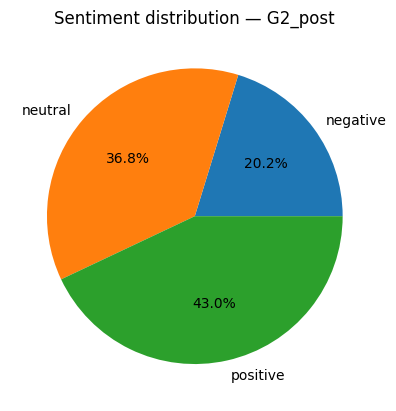

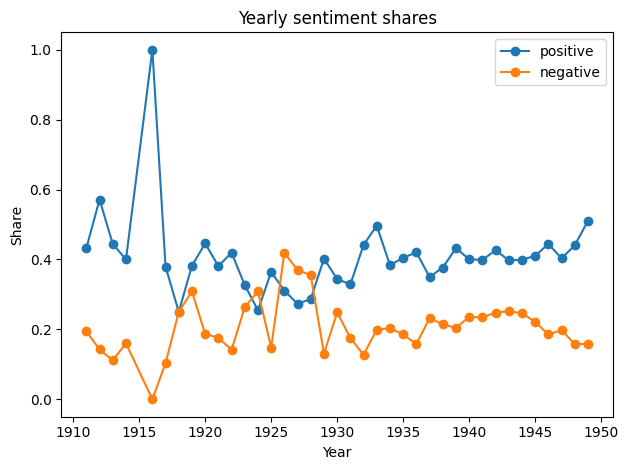

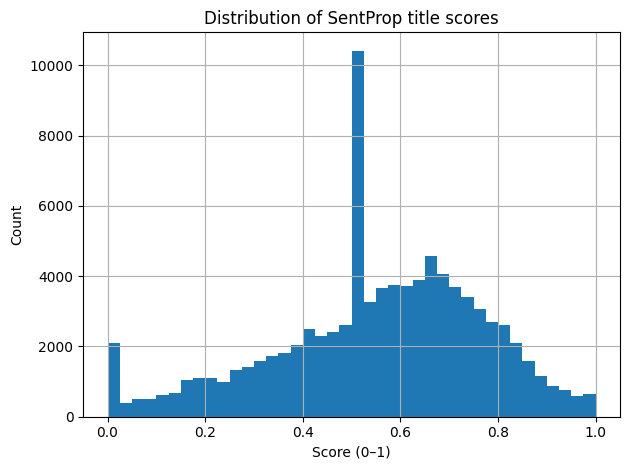

'她' share within each sentiment class:


sp_label_3way,negative,neutral,positive
ta_share,0.002358,0.006132,0.006271


In [15]:
# @title Descriptive summaries & plots (overall / by group / by year)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def infer_year(df):
    """Use 'year' if present; otherwise parse from '_time'."""
    if "year" in df.columns:
        return pd.to_numeric(df["year"], errors="coerce")
    if "_time" in df.columns:
        return pd.to_datetime(df["_time"], errors="coerce").dt.year
    return pd.Series([np.nan]*len(df))

combined["year_infer"] = infer_year(combined)

# ----- Overall class distribution -----
labels = ["negative","neutral","positive"]
dist_all = combined["sp_label_3way"].value_counts(normalize=True)\
            .reindex(labels).fillna(0)
print("Overall 3-way ratios:")
display(dist_all.to_frame("ratio").T)

# ----- By-group distribution (if groups exist) -----
if "_group" in combined.columns:
    dist_grp = (combined.groupby("_group")["sp_label_3way"]
                .value_counts(normalize=True)
                .rename("ratio").reset_index()
                .pivot(index="_group", columns="sp_label_3way", values="ratio")
                .reindex(columns=labels).fillna(0))
    print("By-group 3-way ratios:")
    display(dist_grp)

# ----- Pie charts -----
plt.figure()
plt.pie(dist_all.values, labels=labels, autopct="%.1f%%")
plt.title("Overall sentiment distribution")
plt.show()

if "_group" in combined.columns:
    for g, sub in combined.groupby("_group"):
        d = sub["sp_label_3way"].value_counts(normalize=True).reindex(labels).fillna(0)
        plt.figure()
        plt.pie(d.values, labels=labels, autopct="%.1f%%")
        plt.title(f"Sentiment distribution — {g}")
        plt.show()

# ----- Yearly trend (share of pos/neg) -----
year_tab = (combined.dropna(subset=["year_infer"])
            .groupby("year_infer")["sp_label_3way"]
            .value_counts(normalize=True)
            .rename("ratio").reset_index()
            .pivot(index="year_infer", columns="sp_label_3way", values="ratio")
            .reindex(columns=labels).fillna(0))

plt.figure()
for lab in ["positive","negative"]:
    plt.plot(year_tab.index, year_tab[lab], marker="o", label=lab)
plt.legend()
plt.title("Yearly sentiment shares")
plt.xlabel("Year"); plt.ylabel("Share")
plt.tight_layout(); plt.show()

# ----- Optional: score histogram -----
plt.figure()
combined["sentprop_score"].dropna().hist(bins=40)
plt.title("Distribution of SentProp title scores")
plt.xlabel("Score (0–1)"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

# ----- Optional: '她' share within each sentiment class -----
if "title_has_ta" in combined.columns:
    ta_tab = (combined.groupby("sp_label_3way")["title_has_ta"].mean()
              .reindex(labels).fillna(0))
    print("'她' share within each sentiment class:")
    display(ta_tab.to_frame("ta_share").T)


In [16]:
# @title Install SnowNLP (safe) & compute sentence-level scores
# Do NOT touch numpy/pandas/scipy versions to avoid breaking the environment.
%pip -q install snownlp

from snownlp import SnowNLP
import numpy as np
import pandas as pd

# Compute SnowNLP positive probability in [0,1] for every title
combined["pos_score"] = combined["_title"].astype(str).apply(lambda t: float(SnowNLP(t).sentiments))

# Quick sanity check
combined[["_title","pos_score"]].head(5)


,_title,pos_score
0,野史氏辨狱丛谈,0.958934
1,政党组织之必要,0.473767
2,论大隈伯对待淸国谈之谬妄（续昨）,0.648340
3,学部注最小学教育,0.789887
4,幸未成灾,0.708592


In [17]:
# @title 3-way labeling for SnowNLP (same dynamic thresholds as SentProp)
import numpy as np

# Reuse your thresholds; fallback to defaults if not defined earlier
POS_TH = globals().get("POS_TH", 0.60)
NEG_TH = globals().get("NEG_TH", 0.40)
SHORT_TITLE_LEN = globals().get("SHORT_TITLE_LEN", 6)
SHORT_POS_TH = globals().get("SHORT_POS_TH", 0.65)
SHORT_NEG_TH = globals().get("SHORT_NEG_TH", 0.35)

def dynamic_trilean_label(score, title,
                          base_pos=POS_TH, base_neg=NEG_TH,
                          short_pos=SHORT_POS_TH, short_neg=SHORT_NEG_TH,
                          short_len=SHORT_TITLE_LEN):
    """
    Convert a continuous score to {positive, neutral, negative}.
    Use stricter thresholds for very short titles.
    """
    tlen = len(str(title))
    pos_th = short_pos if tlen < short_len else base_pos
    neg_th = short_neg if tlen < short_len else base_neg
    if score >= pos_th:  return "positive"
    if score <= neg_th:  return "negative"
    return "neutral"

combined["sn_label_3way"] = [dynamic_trilean_label(s, t) for s, t in zip(combined["pos_score"], combined["_title"])]
combined["sn_label_2way"] = np.where(combined["pos_score"]>=0.5, "positive", "negative")

# Quick distribution to compare with SentProp
dist_sn = combined["sn_label_3way"].value_counts(normalize=True)\
          .reindex(["negative","neutral","positive"]).fillna(0)
print("SnowNLP 3-way distribution:")
display(dist_sn.to_frame("ratio").T)


SnowNLP 3-way distribution:


sn_label_3way,negative,neutral,positive
ratio,0.169877,0.25439,0.575733


In [18]:
# Replace the block that prints median |score_diff|
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Ensure mask exists (both scores available)
mask = combined["sentprop_score"].notna() & combined["pos_score"].notna()

# Spearman (you already computed this)
rho, p = spearmanr(combined.loc[mask, "sentprop_score"],
                   combined.loc[mask, "pos_score"])
print(f"Spearman correlation (scores): rho={rho:.3f}, p={p:.2e}")

# Differences
combined["score_diff"] = combined["sentprop_score"] - combined["pos_score"]
combined["abs_diff"]   = combined["score_diff"].abs()

# ✅ FIX: use built-in round() on the float, not .round()
med_abs = float(combined.loc[mask, "abs_diff"].median())
print(f"Median |score_diff|: {round(med_abs, 3)}")

# Optional: percentiles of absolute difference
q = combined.loc[mask, "abs_diff"].quantile([0.5, 0.75, 0.90, 0.95]).round(3)
display(q.to_frame("abs_diff"))

# Show the top disagreements for manual audit
cols = ["_group","year","_title","sentprop_score","pos_score","sp_label_3way","sn_label_3way","abs_diff"]
display(combined.loc[mask].nlargest(15, "abs_diff")[cols])



Spearman correlation (scores): rho=0.077, p=1.35e-117
Median |score_diff|: 0.249


,abs_diff
0.50,0.249
0.75,0.404
0.90,0.556
0.95,0.652


,_group,year,_title,sentprop_score,pos_score,sp_label_3way,sn_label_3way,abs_diff
40334,G2_post,1943.0,“情深意往期无尽 花落水流恨未穷”,0.000000,0.998888,negative,positive,0.998888
83082,G2_post,1949.0,洪雅在贫困中,0.002587,0.999242,negative,positive,0.996655
28613,G2_post,1940.0,万·家灯·火·除·夕·夜·中·的·夜袭,0.004898,0.997895,negative,positive,0.992997
10431,G1_pre,1934.0,[T]中西周率一〇四〇波周……,0.000000,0.991066,negative,positive,0.991066
6285,G1_pre,1932.0,乳母（续）,0.000000,0.990515,negative,positive,0.990515
6290,G1_pre,1932.0,乳母（续）,0.000000,0.990515,negative,positive,0.990515
19308,G1_pre,1937.0,乳母（续）,0.000000,0.990515,negative,positive,0.990515
42336,G2_post,1943.0,[T]（中爽畴牛囚剥捷蹄麓三十一R路唆尝）繁航……,0.000000,0.987526,negative,positive,0.987526
43099,G2_post,1943.0,异国情调•V•W,0.000000,0.987312,negative,positive,0.987312
43110,G2_post,1943.0,异国情调·V·W,0.000000,0.987312,negative,positive,0.987312


Overall class shares (SentProp vs SnowNLP):


,negative,neutral,positive
SentProp,0.204211,0.374356,0.421433
SnowNLP,0.169877,0.254390,0.575733


By-group shares — SentProp:


sp_label_3way,negative,neutral,positive
_group,,,
G1_pre,0.210091,0.396987,0.392923
G2_post,0.202494,0.367750,0.429756


By-group shares — SnowNLP:


sn_label_3way,negative,neutral,positive
_group,,,
G1_pre,0.164098,0.284185,0.551717
G2_post,0.171564,0.245692,0.582744


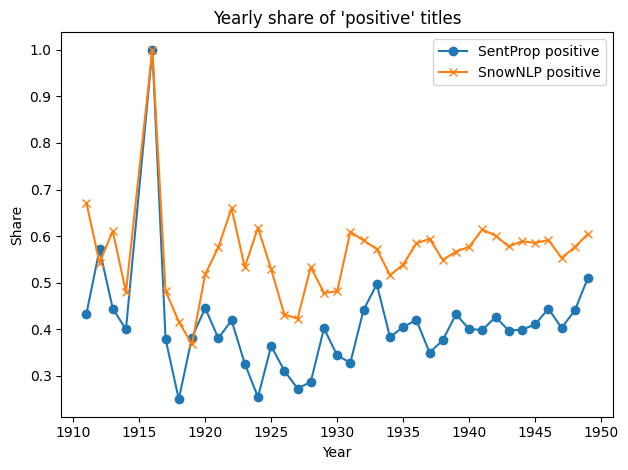

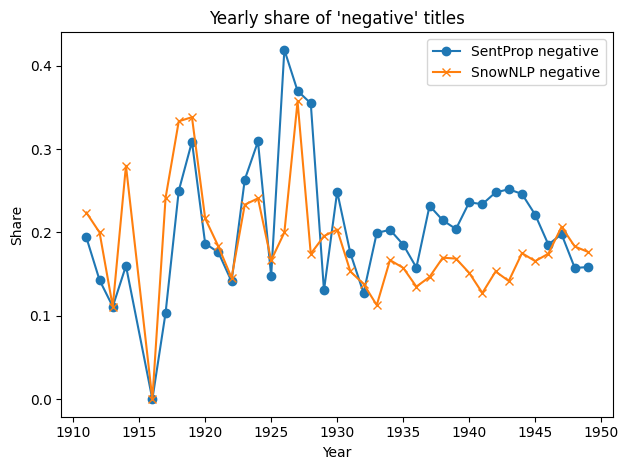

In [19]:
# @title Distribution and yearly trends: SentProp vs SnowNLP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

labels = ["negative","neutral","positive"]

# --- Overall class distribution (side-by-side) ---
dist_sp = combined["sp_label_3way"].value_counts(normalize=True).reindex(labels).fillna(0)
dist_sn = combined["sn_label_3way"].value_counts(normalize=True).reindex(labels).fillna(0)
dist_comp = pd.DataFrame({"SentProp": dist_sp, "SnowNLP": dist_sn}).T
print("Overall class shares (SentProp vs SnowNLP):")
display(dist_comp)

# --- By-group distribution (if available) ---
if "_group" in combined.columns:
    def share_by_group(col):
        return (combined.groupby("_group")[col]
                .value_counts(normalize=True)
                .rename("ratio").reset_index()
                .pivot(index="_group", columns=col, values="ratio")
                .reindex(columns=labels).fillna(0))
    print("By-group shares — SentProp:")
    display(share_by_group("sp_label_3way"))
    print("By-group shares — SnowNLP:")
    display(share_by_group("sn_label_3way"))

# --- Yearly trends: positive & negative shares for both methods ---
def yearly_share(label_col, lab):
    tab = (combined.dropna(subset=["year_infer"])
           .groupby("year_infer")[label_col]
           .apply(lambda s: (s==lab).mean()))
    tab = tab.sort_index()
    return tab

for lab in ["positive","negative"]:
    sp_y = yearly_share("sp_label_3way", lab)
    sn_y = yearly_share("sn_label_3way", lab)
    plt.figure()
    plt.plot(sp_y.index, sp_y.values, marker="o", label=f"SentProp {lab}")
    plt.plot(sn_y.index, sn_y.values, marker="x", label=f"SnowNLP {lab}")
    plt.legend()
    plt.title(f"Yearly share of '{lab}' titles")
    plt.xlabel("Year"); plt.ylabel("Share")
    plt.tight_layout(); plt.show()


In [20]:
# @title Export final sentiment table (SentProp primary)
import pandas as pd

cols = ["_dataset","_group","_title","_time","year","year_infer",
        "title_has_ta","lex_hits","sentprop_score","sp_label_3way","sp_label_2way"]
cols = [c for c in cols if c in combined.columns]

final = combined[cols].copy()
csv_path = f"{OUTDIR}/final_sentiment_sentprop.csv"
final.to_csv(csv_path, index=False, encoding="utf-8-sig")
print("Saved ->", csv_path)

try:
    xlsx_path = f"{OUTDIR}/final_sentiment_sentprop.xlsx"
    final.to_excel(xlsx_path, index=False)
    print("Saved ->", xlsx_path)
except Exception:
    pass

final.head(10)


Saved -> /content/outputs_nlp/final_sentiment_sentprop.csv
Saved -> /content/outputs_nlp/final_sentiment_sentprop.xlsx


,_dataset,_group,_title,_time,year,year_infer,title_has_ta,lex_hits,sentprop_score,sp_label_3way,sp_label_2way
0,1911-1937,G1_pre,野史氏辨狱丛谈,1911-01-11,1911.0,1911.0,0,1,0.791328,positive,positive
1,1911-1937,G1_pre,政党组织之必要,1911-01-17,1911.0,1911.0,0,3,0.720829,positive,positive
2,1911-1937,G1_pre,论大隈伯对待淸国谈之谬妄（续昨）,1911-01-20,1911.0,1911.0,0,1,0.268679,negative,negative
3,1911-1937,G1_pre,学部注最小学教育,1911-02-02,1911.0,1911.0,0,3,0.644851,positive,positive
4,1911-1937,G1_pre,幸未成灾,1911-02-06,1911.0,1911.0,0,1,0.079015,negative,negative
5,1911-1937,G1_pre,今日是中西医大决战之时机,1911-02-21,1911.0,1911.0,0,3,0.590861,neutral,positive
6,1911-1937,G1_pre,[T]我知道色字当戒然而我在南京路福州路一带见一般艳妆妇女……,1911-02-22,1911.0,1911.0,0,5,0.491537,neutral,negative
7,1911-1937,G1_pre,折衷社之反对论,1911-03-06,1911.0,1911.0,0,2,0.484109,neutral,negative
8,1911-1937,G1_pre,焕然一新,1911-03-13,1911.0,1911.0,0,0,0.500000,neutral,positive
9,1911-1937,G1_pre,试行新币法,1911-03-18,1911.0,1911.0,0,1,0.259645,negative,negative


In [21]:
# Cell 5: DID (post-1937) — robustness specification
formula_lpm_post = f"y_pos ~ female_mention + post1937 + female_mention:post1937 + {base_controls}"

lpm_post = smf.ols(formula=formula_lpm_post, data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["year"]}
)

keys_post = ["female_mention","post1937","female_mention:post1937","lex_hits","title_len","n_qmark","n_exclam","has_digit","has_quote"]
lpm_post_tab = tidy_lpm(lpm_post, keys_post)

print(lpm_post.summary())
lpm_post_tab


NameError: name 'base_controls' is not defined